In [1]:
import pandas as pd
import xarray as xr
import gcsfs
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# gcs = gcsfs.GCSFileSystem(token='anon')
# df = pd.read_csv('https://storage.googleapis.com/cmip6/cmip6-zarr-consolidated-stores.csv')
# print("Catalog loaded:", df.shape)

In [2]:
target_models = ['CESM2', 'GFDL-ESM4', 'MPI-ESM1-2-HR', 'IPSL-CM6A-LR']
scenarios = ['ssp126', 'ssp245', 'ssp370', 'ssp585']

In [3]:
all_records = []

for model in target_models:
    print(f"\nLoading historical — {model}...")

    row = df.query(
        f"source_id == '{model}' & "
        "experiment_id == 'historical' & "
        "variable_id == 'tas' & "
        "table_id == 'Amon' & "
        "member_id == 'r1i1p1f1'"
    )

    if row.empty:
        print(f"  Skipping {model} — no historical store found")
        continue

    try:
        ds = xr.open_zarr(gcs.get_mapper(row.iloc[0].zstore), consolidated=True)

        # Global mean: weight by cosine of latitude
        weights = np.cos(np.deg2rad(ds.lat))
        tas_global = ds.tas.weighted(weights).mean(dim=['lat', 'lon'])
        tas_global = tas_global.load()

        for i, t in enumerate(tas_global.time.values):
            all_records.append({
                'model':    model,
                'scenario': 'historical',
                'time':     str(t)[:7],   # YYYY-MM
                'year':     int(str(t)[:4]),
                'tas_c':    float(tas_global.values[i]) - 273.15
            })

        print(f"  Done — {len(tas_global.time.values)} months")

    except Exception as e:
        print(f"  Failed: {e}")

print(f"\nHistorical records so far: {len(all_records)}")


Loading historical — CESM2...


I0518 19:14:26.327486  125530 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0518 19:14:26.334512  125546 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(88, generation: 1)


  Done — 1980 months

Loading historical — GFDL-ESM4...
  Done — 1980 months

Loading historical — MPI-ESM1-2-HR...
  Done — 1980 months

Loading historical — IPSL-CM6A-LR...
  Done — 1980 months

Historical records so far: 7920


In [10]:
# Member ID varies by model — define explicitly
member_ids = {
    'CESM2':         'r4i1p1f1',   # CESM2 doesn't have r1i1p1f1 for SSP
    'GFDL-ESM4':     'r1i1p1f1',
    'MPI-ESM1-2-HR': 'r1i1p1f1',
    'IPSL-CM6A-LR':  'r1i1p1f1',
}

for scenario in scenarios:
    for model in target_models:
        member = member_ids[model]
        print(f"Loading {scenario} — {model} ({member})...")

        row = df.query(
            f"source_id == '{model}' & "
            f"experiment_id == '{scenario}' & "
            "variable_id == 'tas' & "
            "table_id == 'Amon' & "
            f"member_id == '{member}'"
        )

        if row.empty:
            print(f"  Skipping — no store found")
            continue

        try:
            ds = xr.open_zarr(gcs.get_mapper(row.iloc[0].zstore), consolidated=True)

            weights = np.cos(np.deg2rad(ds.lat))
            tas_global = ds.tas.weighted(weights).mean(dim=['lat', 'lon'])
            tas_global = tas_global.load()

            for i, t in enumerate(tas_global.time.values):
                all_records.append({
                    'model':    model,
                    'scenario': scenario,
                    'time':     str(t)[:7],
                    'year':     int(str(t)[:4]),
                    'tas_c':    float(tas_global.values[i]) - 273.15
                })

            print(f"  Done — {len(tas_global.time.values)} months")

        except Exception as e:
            print(f"  Failed: {e}")

print(f"\nTotal records: {len(all_records)}")

Loading ssp126 — CESM2 (r4i1p1f1)...
  Done — 1032 months
Loading ssp126 — GFDL-ESM4 (r1i1p1f1)...
  Done — 1032 months
Loading ssp126 — MPI-ESM1-2-HR (r1i1p1f1)...
  Done — 1032 months
Loading ssp126 — IPSL-CM6A-LR (r1i1p1f1)...
  Done — 1032 months
Loading ssp245 — CESM2 (r4i1p1f1)...
  Done — 1032 months
Loading ssp245 — GFDL-ESM4 (r1i1p1f1)...
  Done — 1032 months
Loading ssp245 — MPI-ESM1-2-HR (r1i1p1f1)...
  Done — 1032 months
Loading ssp245 — IPSL-CM6A-LR (r1i1p1f1)...
  Done — 1032 months
Loading ssp370 — CESM2 (r4i1p1f1)...
  Done — 1032 months
Loading ssp370 — GFDL-ESM4 (r1i1p1f1)...
  Done — 1032 months
Loading ssp370 — MPI-ESM1-2-HR (r1i1p1f1)...
  Done — 1032 months
Loading ssp370 — IPSL-CM6A-LR (r1i1p1f1)...
  Done — 1032 months
Loading ssp585 — CESM2 (r4i1p1f1)...
  Done — 1032 months
Loading ssp585 — GFDL-ESM4 (r1i1p1f1)...
  Done — 1032 months
Loading ssp585 — MPI-ESM1-2-HR (r1i1p1f1)...
  Done — 1032 months
Loading ssp585 — IPSL-CM6A-LR (r1i1p1f1)...
  Done — 1032 mon

In [11]:
df_all = pd.DataFrame(all_records)

# ── Baseline: pre-industrial 1850–1900 mean per model ──────────────────────
baseline = (
    df_all
    .query("scenario == 'historical' and year >= 1850 and year <= 1900")
    .groupby('model')['tas_c']
    .mean()
    .reset_index()
    .rename(columns={'tas_c': 'tas_baseline'})
)

df_all = df_all.merge(baseline, on='model', how='left')
df_all['anomaly'] = (df_all['tas_c'] - df_all['tas_baseline']).round(4)

# ── Annual mean (cleaner for visualization than monthly) ───────────────────
df_annual = (
    df_all
    .groupby(['model', 'scenario', 'year'])
    .agg(
        tas_c    = ('tas_c',   'mean'),
        anomaly  = ('anomaly', 'mean')
    )
    .reset_index()
    .round(4)
)

# ── Stitch historical + SSP (historical ends 2014, SSP starts 2015) ────────
df_annual = df_annual.sort_values(['model', 'scenario', 'year'])

print("Scenarios present:", df_annual['scenario'].unique())
print("Models present:",    df_annual['model'].unique())
print("Year range:",        df_annual['year'].min(), "–", df_annual['year'].max())
print("Shape:", df_annual.shape)
print(df_annual.head(10))

# ── Export ─────────────────────────────────────────────────────────────────
df_annual.to_csv('cmip6_global_anomaly.csv', index=False)
print("\nSaved cmip6_global_anomaly.csv")

Scenarios present: ['historical' 'ssp126' 'ssp245' 'ssp370' 'ssp585']
Models present: ['CESM2' 'GFDL-ESM4' 'IPSL-CM6A-LR' 'MPI-ESM1-2-HR']
Year range: 1850 – 2100
Shape: (2036, 5)
   model    scenario  year    tas_c  anomaly
0  CESM2  historical  1850  14.0557   0.0304
1  CESM2  historical  1851  14.1470   0.1217
2  CESM2  historical  1852  13.9846  -0.0407
3  CESM2  historical  1853  13.9875  -0.0378
4  CESM2  historical  1854  13.9497  -0.0756
5  CESM2  historical  1855  13.8035  -0.2218
6  CESM2  historical  1856  13.9299  -0.0954
7  CESM2  historical  1857  14.0245  -0.0008
8  CESM2  historical  1858  13.8952  -0.1301
9  CESM2  historical  1859  14.0494   0.0241

Saved cmip6_global_anomaly.csv


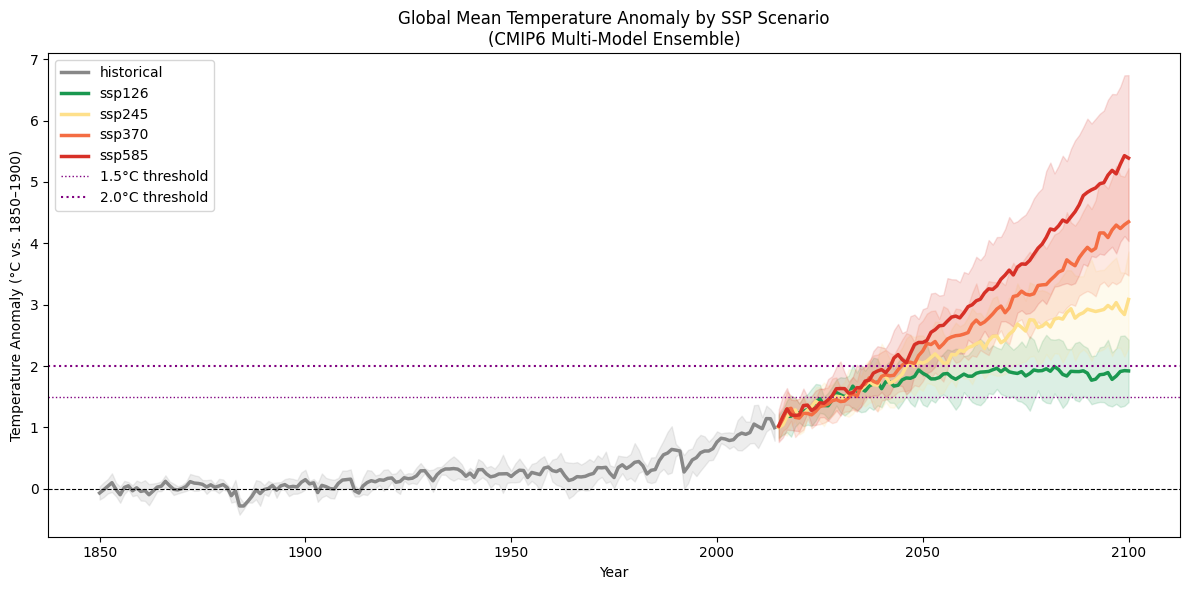

In [12]:
scenario_colors = {
    'historical': '#888888',
    'ssp126':     '#1a9850',   # green  — best case
    'ssp245':     '#fee08b',   # yellow — middle
    'ssp370':     '#f46d43',   # orange — middle-high
    'ssp585':     '#d73027'    # red    — worst case
}

fig, ax = plt.subplots(figsize=(12, 6))

for scenario, grp in df_annual.groupby('scenario'):
    # Plot each model as thin line, ensemble mean as thick line
    model_means = grp.groupby('year')['anomaly'].mean()
    model_std   = grp.groupby('year')['anomaly'].std()

    color = scenario_colors.get(scenario, 'black')
    ax.plot(model_means.index, model_means.values,
            color=color, linewidth=2.5, label=scenario)
    ax.fill_between(model_means.index,
                    model_means - model_std,
                    model_means + model_std,
                    color=color, alpha=0.15)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axhline(1.5, color='purple', linewidth=1, linestyle=':', label='1.5°C threshold')
ax.axhline(2.0, color='purple', linewidth=1.5, linestyle=':', label='2.0°C threshold')
ax.set_xlabel("Year")
ax.set_ylabel("Temperature Anomaly (°C vs. 1850–1900)")
ax.set_title("Global Mean Temperature Anomaly by SSP Scenario\n(CMIP6 Multi-Model Ensemble)")
ax.legend()
plt.tight_layout()
plt.savefig('proposal_viz1_anomaly.png', dpi=150)
plt.show()

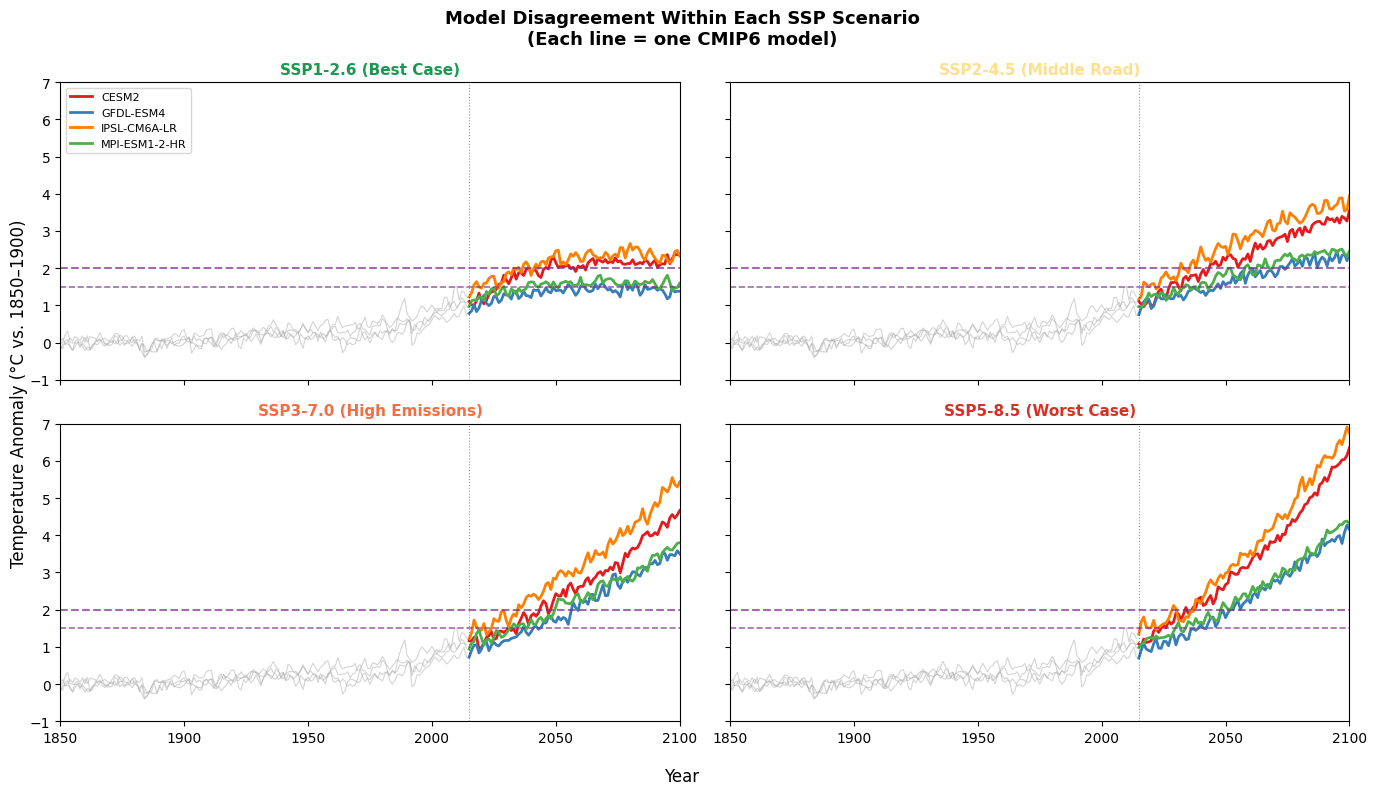

✅ Saved proposal_viz2_model_spread.png


In [16]:
# ── Viz 2 — Per-model lines within each scenario (shows inter-model spread) 
scenario_labels = {
    'historical': 'Historical',
    'ssp126':     'SSP1-2.6 (Best Case)',
    'ssp245':     'SSP2-4.5 (Middle Road)',
    'ssp370':     'SSP3-7.0 (High Emissions)',
    'ssp585':     'SSP5-8.5 (Worst Case)'
}

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
axes = axes.flatten()

ssp_scenarios = ['ssp126', 'ssp245', 'ssp370', 'ssp585']
model_colors  = {
    'CESM2':         '#e41a1c',
    'GFDL-ESM4':     '#377eb8',
    'MPI-ESM1-2-HR': '#4daf4a',
    'IPSL-CM6A-LR':  '#ff7f00'
}

for i, scenario in enumerate(ssp_scenarios):
    ax = axes[i]

    # Plot historical as grey background on each panel
    hist = df_annual.query("scenario == 'historical'")
    for model, grp in hist.groupby('model'):
        ax.plot(grp['year'], grp['anomaly'],
                color='#aaaaaa', linewidth=0.8, alpha=0.5)

    # Plot each model's SSP trajectory
    ssp = df_annual.query(f"scenario == '{scenario}'")
    for model, grp in ssp.groupby('model'):
        ax.plot(grp['year'], grp['anomaly'],
                color=model_colors[model], linewidth=2,
                label=model)

    ax.axhline(1.5, color='#7b2d8b', linewidth=1.2, linestyle='--', alpha=0.7)
    ax.axhline(2.0, color='#7b2d8b', linewidth=1.5, linestyle='--', alpha=0.7)
    ax.set_title(scenario_labels[scenario], fontsize=11, fontweight='bold',
                 color=scenario_colors[scenario])
    ax.set_xlim(1850, 2100)
    ax.set_ylim(-1, 7)
    ax.axvline(2015, color='black', linewidth=0.8, linestyle=':', alpha=0.4)

axes[0].legend(fontsize=8, loc='upper left')
fig.supxlabel("Year", fontsize=12)
fig.supylabel("Temperature Anomaly (°C vs. 1850–1900)", fontsize=12)
fig.suptitle("Model Disagreement Within Each SSP Scenario\n(Each line = one CMIP6 model)",
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('proposal_viz2_model_spread.png', dpi=150)
plt.show()
print("✅ Saved proposal_viz2_model_spread.png")

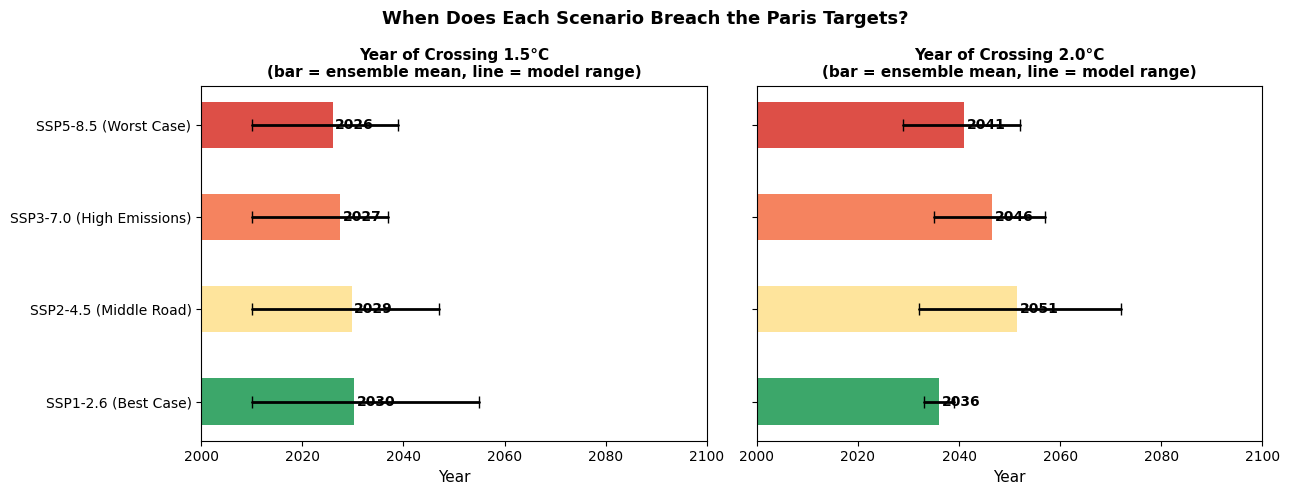

✅ Saved proposal_viz3_crossing_years.png


In [17]:
# ── Viz 3 — What year does each scenario cross 1.5°C and 2.0°C? ────────────

thresholds = [1.5, 2.0]
crossing_records = []

for scenario in ssp_scenarios:
    for model in df_annual['model'].unique():
        # Stitch historical + scenario together for continuous series
        hist = df_annual.query(f"scenario == 'historical' and model == '{model}'")
        ssp  = df_annual.query(f"scenario == '{scenario}' and model == '{model}'")
        combined = pd.concat([hist, ssp]).sort_values('year')

        for threshold in thresholds:
            crossed = combined[combined['anomaly'] >= threshold]
            if not crossed.empty:
                crossing_records.append({
                    'model':     model,
                    'scenario':  scenario,
                    'threshold': threshold,
                    'year':      crossed['year'].iloc[0]
                })

df_cross = pd.DataFrame(crossing_records)

# ── Plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, threshold in zip(axes, thresholds):
    data = df_cross[df_cross['threshold'] == threshold]

    # Ensemble mean crossing year per scenario
    means = data.groupby('scenario')['year'].mean().reindex(ssp_scenarios)
    mins  = data.groupby('scenario')['year'].min().reindex(ssp_scenarios)
    maxs  = data.groupby('scenario')['year'].max().reindex(ssp_scenarios)

    colors = [scenario_colors[s] for s in ssp_scenarios]
    labels = [scenario_labels[s] for s in ssp_scenarios]

    bars = ax.barh(labels, means, color=colors, alpha=0.85, height=0.5)

    # Add error bars showing model spread
    for j, scenario in enumerate(ssp_scenarios):
        ax.plot([mins[scenario], maxs[scenario]], [j, j],
                color='black', linewidth=2, solid_capstyle='round')
        ax.plot(mins[scenario], j, '|', color='black', markersize=8)
        ax.plot(maxs[scenario], j, '|', color='black', markersize=8)

    # Label mean year on each bar
    for j, (scenario, bar) in enumerate(zip(ssp_scenarios, bars)):
        ax.text(means[scenario] + 0.5, j, f"{int(means[scenario])}",
                va='center', fontsize=10, fontweight='bold')

    ax.set_xlabel("Year", fontsize=11)
    ax.set_title(f"Year of Crossing {threshold}°C\n(bar = ensemble mean, line = model range)",
                 fontsize=11, fontweight='bold')
    ax.set_xlim(2000, 2100)
    ax.invert_yaxis()

fig.suptitle("When Does Each Scenario Breach the Paris Targets?", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('proposal_viz3_crossing_years.png', dpi=150)
plt.show()
print("✅ Saved proposal_viz3_crossing_years.png")

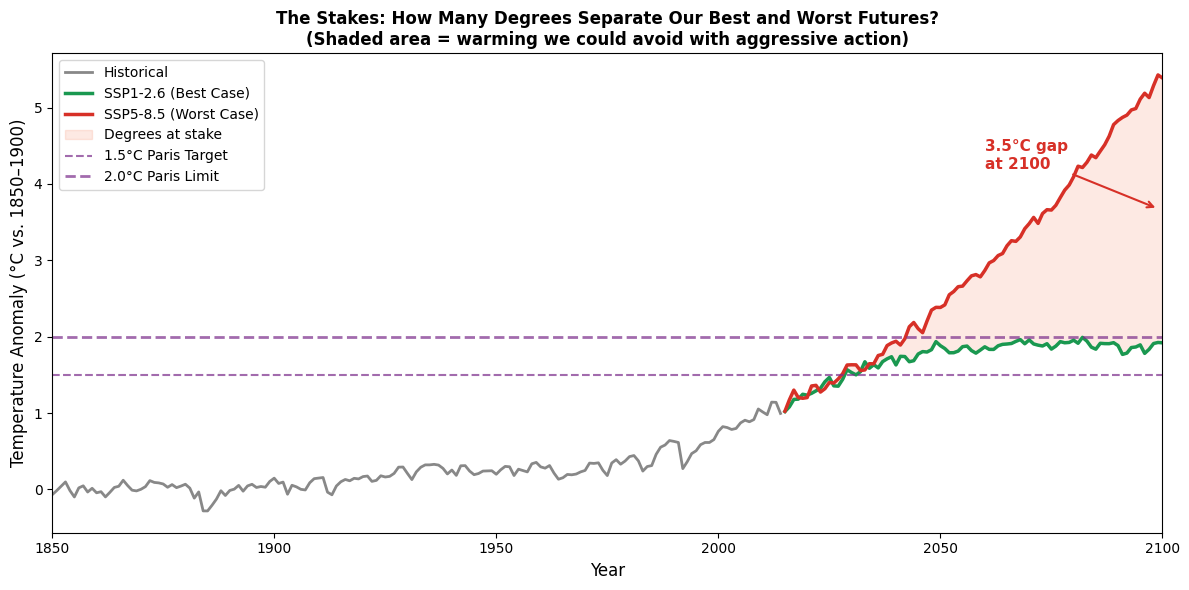

✅ Saved proposal_viz4_stakes_gap.png


In [18]:
# ── Viz 4 — The stakes: gap between SSP1-2.6 and SSP5-8.5 over time ────────

fig, ax = plt.subplots(figsize=(12, 6))

# Ensemble means per scenario per year
means = df_annual.groupby(['scenario', 'year'])['anomaly'].mean().reset_index()

best  = means[means['scenario'] == 'ssp126'].set_index('year')['anomaly']
worst = means[means['scenario'] == 'ssp585'].set_index('year')['anomaly']
hist  = means[means['scenario'] == 'historical'].set_index('year')['anomaly']

# Align years
common_ssp  = best.index.intersection(worst.index)
gap = (worst - best).loc[common_ssp]

# Plot historical first
ax.plot(hist.index, hist.values, color='#888888', linewidth=2, label='Historical')

# Plot best and worst
ax.plot(best.index,  best.values,  color='#1a9850', linewidth=2.5, label='SSP1-2.6 (Best Case)')
ax.plot(worst.index, worst.values, color='#d73027', linewidth=2.5, label='SSP5-8.5 (Worst Case)')

# Fill the gap between them
ax.fill_between(common_ssp, best.loc[common_ssp], worst.loc[common_ssp],
                alpha=0.15, color='#f46d43', label='Degrees at stake')

# Annotate the gap at 2100
gap_2100 = gap.loc[2099] if 2099 in gap.index else gap.iloc[-1]
ax.annotate(f'{gap_2100:.1f}°C gap\nat 2100',
            xy=(2099, (best.loc[2099] + worst.loc[2099]) / 2),
            xytext=(2060, 4.2),
            fontsize=11, fontweight='bold', color='#d73027',
            arrowprops=dict(arrowstyle='->', color='#d73027', lw=1.5))

# Paris thresholds
ax.axhline(1.5, color='#7b2d8b', linewidth=1.5, linestyle='--', alpha=0.7, label='1.5°C Paris Target')
ax.axhline(2.0, color='#7b2d8b', linewidth=2.0, linestyle='--', alpha=0.7, label='2.0°C Paris Limit')

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Temperature Anomaly (°C vs. 1850–1900)", fontsize=12)
ax.set_title("The Stakes: How Many Degrees Separate Our Best and Worst Futures?\n"
             "(Shaded area = warming we could avoid with aggressive action)",
             fontsize=12, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.set_xlim(1850, 2100)

plt.tight_layout()
plt.savefig('proposal_viz4_stakes_gap.png', dpi=150)
plt.show()
print("✅ Saved proposal_viz4_stakes_gap.png")

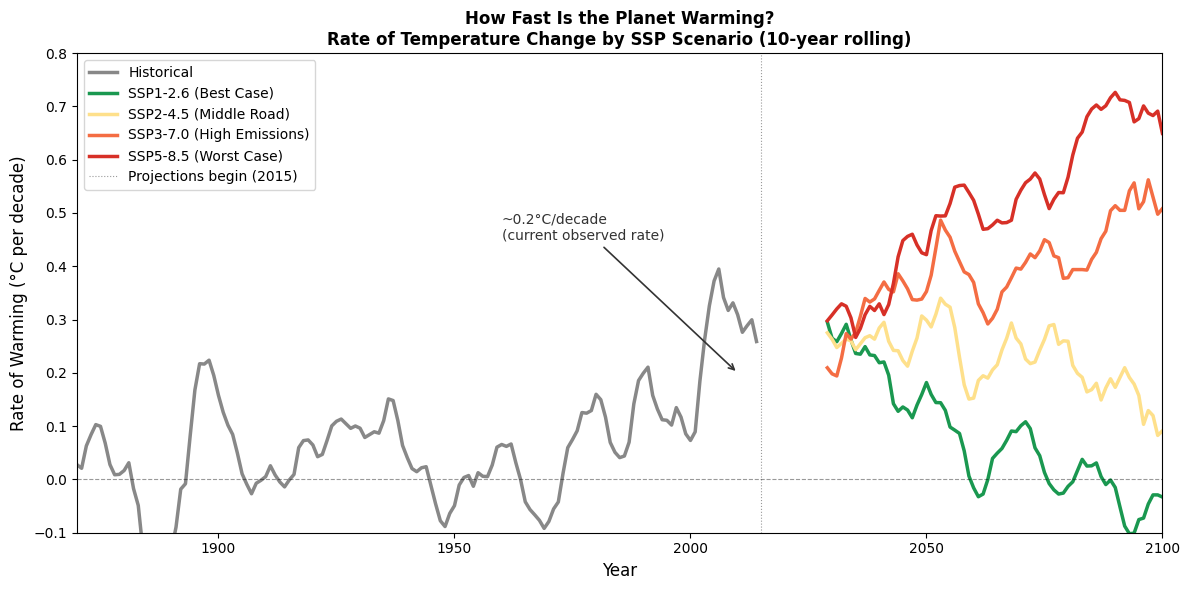

✅ Saved proposal_viz5_warming_rate.png


In [19]:
# ── Viz 5 — Rate of warming (10-year rolling slope per scenario) ─────────────

fig, ax = plt.subplots(figsize=(12, 6))

for scenario in ['historical'] + ssp_scenarios:
    grp = means[means['scenario'] == scenario].set_index('year')['anomaly']
    
    # 10-year rolling rate of change (°C per decade)
    rate = grp.diff(10) / 10 * 10   # °C per decade
    rate = rate.rolling(5).mean()    # smooth slightly

    color = scenario_colors[scenario]
    label = scenario_labels[scenario]
    ax.plot(grp.index, rate.values, color=color, linewidth=2.5, label=label)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
ax.axvline(2015, color='black', linewidth=0.8, linestyle=':', alpha=0.4, label='Projections begin (2015)')

# Annotate current observed rate
ax.annotate('~0.2°C/decade\n(current observed rate)',
            xy=(2010, 0.2),
            xytext=(1960, 0.45),
            fontsize=10, color='#333333',
            arrowprops=dict(arrowstyle='->', color='#333333', lw=1.2))

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Rate of Warming (°C per decade)", fontsize=12)
ax.set_title("How Fast Is the Planet Warming?\n"
             "Rate of Temperature Change by SSP Scenario (10-year rolling)",
             fontsize=12, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.set_xlim(1870, 2100)
ax.set_ylim(-0.1, 0.8)

plt.tight_layout()
plt.savefig('proposal_viz5_warming_rate.png', dpi=150)
plt.show()
print("✅ Saved proposal_viz5_warming_rate.png")

### Keeling Data

In [2]:
url = 'https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.csv'

df_co2 = pd.read_csv(url, comment='#', header=0)

print(df_co2.columns.tolist())
print(df_co2.head())

['year', 'month', 'decimal date', 'average', 'deseasonalized', 'ndays', 'sdev', 'unc']
   year  month  decimal date  average  deseasonalized  ndays  sdev   unc
0  1958      3     1958.2027   315.71          314.44     -1 -9.99 -0.99
1  1958      4     1958.2877   317.45          315.16     -1 -9.99 -0.99
2  1958      5     1958.3699   317.51          314.69     -1 -9.99 -0.99
3  1958      6     1958.4548   317.27          315.15     -1 -9.99 -0.99
4  1958      7     1958.5370   315.87          315.20     -1 -9.99 -0.99


In [4]:
df_keeling = df_co2[['year', 'month', 'decimal date', 'average', 'deseasonalized']].copy()

df_keeling.columns = ['year', 'month', 'decimal_date', 'co2_raw', 'co2_smooth']

df_keeling['co2_raw']    = df_keeling['co2_raw'].replace(-99.99, float('nan'))
df_keeling['co2_smooth'] = df_keeling['co2_smooth'].replace(-99.99, float('nan'))

df_keeling = df_keeling.dropna(subset=['co2_raw', 'co2_smooth'], how='all')

print(f"Rows: {len(df_keeling)}")
print(f"Years: {df_keeling['year'].min()} – {df_keeling['year'].max()}")
print(f"CO₂ range: {df_keeling['co2_raw'].min():.2f} – {df_keeling['co2_raw'].max():.2f} ppm")
print(df_keeling.head())

df_keeling.to_csv('keeling.csv', index=False)
print("\n✅ Saved keeling.csv")

Rows: 818
Years: 1958 – 2026
CO₂ range: 312.42 – 431.12 ppm
   year  month  decimal_date  co2_raw  co2_smooth
0  1958      3     1958.2027   315.71      314.44
1  1958      4     1958.2877   317.45      315.16
2  1958      5     1958.3699   317.51      314.69
3  1958      6     1958.4548   317.27      315.15
4  1958      7     1958.5370   315.87      315.20

✅ Saved keeling.csv


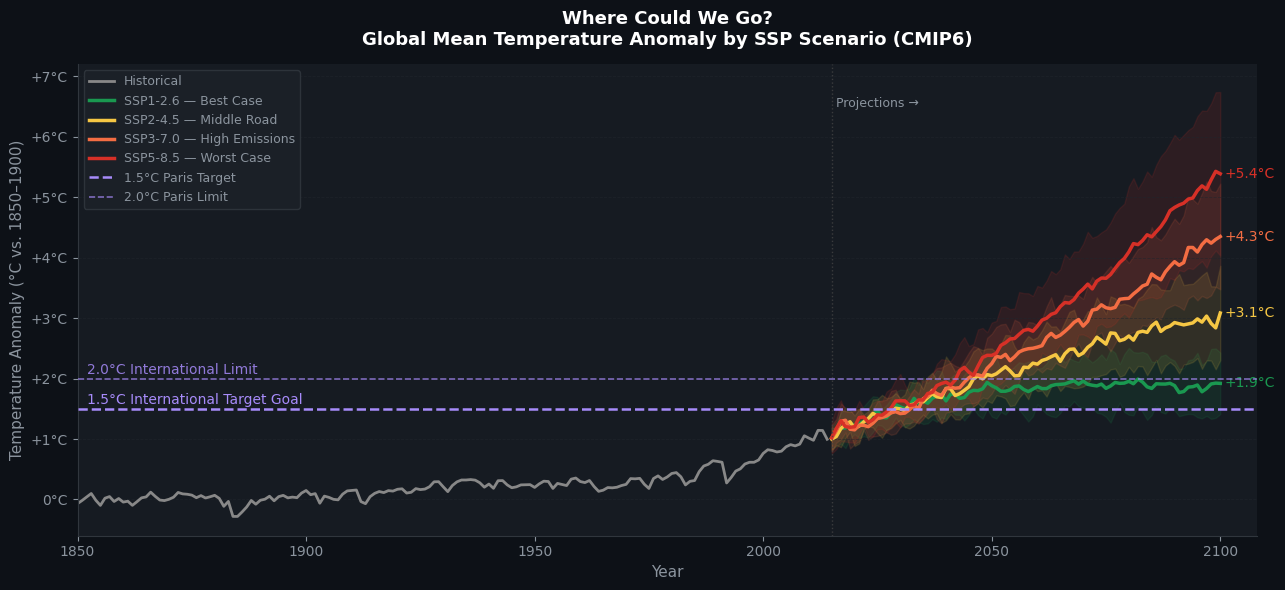

✅ Saved fan_chart_paris_annotated.png


In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

df = pd.read_csv('cmip6_global_anomaly.csv')

scenario_colors = {
    'historical': '#888888',
    'ssp126':     '#1a9850',
    'ssp245':     '#f6c744',
    'ssp370':     '#f46d43',
    'ssp585':     '#d73027'
}

scenario_labels = {
    'historical': 'Historical',
    'ssp126':     'SSP1-2.6 — Best Case',
    'ssp245':     'SSP2-4.5 — Middle Road',
    'ssp370':     'SSP3-7.0 — High Emissions',
    'ssp585':     'SSP5-8.5 — Worst Case'
}

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

for scenario, color in scenario_colors.items():
    grp = df[df['scenario'] == scenario]
    means = grp.groupby('year')['anomaly'].mean()
    stds  = grp.groupby('year')['anomaly'].std()

    ax.plot(means.index, means.values,
            color=color, linewidth=2.5 if scenario != 'historical' else 2,
            label=scenario_labels[scenario])

    if scenario != 'historical':
        ax.fill_between(means.index,
                        means - stds, means + stds,
                        color=color, alpha=0.12)

        # end label
        ax.text(2101, means.iloc[-1],
                f"+{means.iloc[-1]:.1f}°C",
                color=color, fontsize=10,
                va='center', fontfamily='sans-serif')

# ── Paris threshold lines ────────────────────────────────────
ax.axhline(1.5, color='#a78bfa', linewidth=1.8,
           linestyle='--', zorder=5, label='1.5°C Paris Target')
ax.axhline(2.0, color='#a78bfa', linewidth=1.2,
           linestyle='--', zorder=5, alpha=0.7, label='2.0°C Paris Limit')

ax.text(1852, 1.5 + 0.08, '1.5°C International Target Goal',
        color='#a78bfa', fontsize=10, fontfamily='sans-serif')
ax.text(1852, 2.0 + 0.08, '2.0°C International Limit',
        color='#a78bfa', fontsize=10, fontfamily='sans-serif', alpha=0.85)

# ── 2015 handoff ─────────────────────────────────────────────
ax.axvline(2015, color='#444444', linewidth=1,
           linestyle=':', alpha=0.8)
ax.text(2016, 6.5, 'Projections →',
        color='#8b949e', fontsize=9, fontfamily='sans-serif')

# ── Styling ──────────────────────────────────────────────────
ax.set_xlim(1850, 2108)
ax.set_ylim(-0.6, 7.2)
ax.set_xlabel('Year', color='#8b949e', fontsize=11)
ax.set_ylabel('Temperature Anomaly (°C vs. 1850–1900)',
              color='#8b949e', fontsize=11)
ax.set_title('Where Could We Go?\nGlobal Mean Temperature Anomaly by SSP Scenario (CMIP6)',
             color='#ffffff', fontsize=13, fontweight='bold', pad=14)

ax.tick_params(colors='#8b949e')
ax.spines['bottom'].set_color('#30363d')
ax.spines['left'].set_color('#30363d')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda v, _: f'+{v:.0f}°C' if v > 0 else f'{v:.0f}°C'))

ax.grid(axis='y', color='#21262d', linestyle='--',
        linewidth=0.6, alpha=0.6)

ax.legend(loc='upper left', fontsize=9,
          facecolor='#1c2128', edgecolor='#30363d',
          labelcolor='#8b949e', framealpha=0.9)

plt.tight_layout()
plt.savefig('fan_chart_paris_annotated.png', dpi=180,
            facecolor='#0d1117', bbox_inches='tight')
plt.show()
print("✅ Saved fan_chart_paris_annotated.png")